<a href="https://colab.research.google.com/github/aniget/SoftUni-AI-Integrations-for-developers/blob/main/AI_Tutor_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 AI Learning Assistant — RAG-Powered Educational Tutor

> **Built with:** Claude API · ChromaDB · SentenceTransformers · PyMuPDF · Coqui XTTS v2 · gTTS · HuggingFace FLUX

---

## What This Notebook Teaches

This notebook is intentionally **dual-purpose**:

| Audience | What you get |
|---|---|
| 🧒 **Students (end users)** | An AI tutor that reads your PDF and answers questions in your language and age level — as text, voice, or illustration |
| 🎓 **Engineering students** | Hands-on RAG architecture, vector databases, embeddings, LLM prompt engineering, neural TTS, and model distribution |

---
---

## Setup Reference
| Area | Section |
|---|---|
|   **Environment**  | Section 1 |
| **Optional: Upload a Custom Speaker Voice** | Section 7c |
| **PDF Document Upload** | Section 8 |
| **Student** | Section 9 |
---
## Required
```
ANTHROPIC API KEY — for AI Model calling
HuggingFace Token — for Image Generation
Optional: Access to XTTS V2 Fine-tuned Bulgarian Audio Model Repo - for better bg audio
```

## System Architecture

```
USER INPUT  (question + student profile + language)
       ↓
ask_ai()  ←  intent detection via Claude (structured JSON output)
       ↓
retrieve_information()
   1. Embed query      →  SentenceTransformer (local, free)
   2. Similarity search →  ChromaDB HNSW index (top-k chunks)
   3. Assemble context  →  labelled blocks with page attribution
   4. Generate answer   →  Claude API (grounded, profile-adapted)
       ↓
OUTPUT ROUTER
   text  →  Markdown display
   audio →  XTTS v2 fine-tuned BG model  |  gTTS fallback (EN)
   image →  HuggingFace FLUX illustration
```

---

## Key Engineering Concepts Covered

- **Chunking strategy** — why size and overlap determine retrieval quality
- **Dense embeddings** — how sentences become vectors, why cosine similarity works
- **Vector databases** — ChromaDB internals and the HNSW index
- **Prompt engineering** — structured output, anti-hallucination, profile adaptation
- **Neural TTS** — XTTS v2 zero-shot voice cloning and chunked synthesis
- **Model distribution** — pulling fine-tuned weights from HuggingFace Hub
- **Learner psychology** — evidence-based engagement strategies baked into the system prompt


---
## 📦 Section 1 — Environment Setup

### Engineering Note: Dependency Management

| Library | Role |
|---|---|
| `anthropic` | Claude API — LLM backbone for generation and intent detection |
| `chromadb` | In-memory vector store with HNSW approximate nearest-neighbour indexing |
| `sentence-transformers` | Local embedding model — zero API cost, ~5 ms per chunk |
| `pymupdf` (fitz) | Fast, accurate PDF text extraction |
| `TTS` (Coqui) | XTTS v2 architecture — loads the fine-tuned Bulgarian checkpoint |
| `gtts` | Google TTS — English fallback (cloud, no GPU required) |
| `huggingface_hub` | Downloads XTTS model files from my private HF repo |
| `Pillow` | Decodes JPEG bytes returned by the HF Inference API |
| `scipy` | WAV file I/O for XTTS audio output |

> **Why a local embedding model?**
> Embedding runs on every chunk at index time AND on every query.
> `all-MiniLM-L6-v2` (~80 MB) costs zero per call; API embeddings add latency and money at scale.


In [ ]:
# ─── Install dependencies ────────────────────────────────────────────────────
# Re-run this cell if the Colab runtime is restarted (environment resets).

!pip install -q anthropic chromadb sentence-transformers pymupdf gtts Pillow requests huggingface_hub scipy

# Coqui TTS provides the XTTS v2 architecture for the fine-tuned BG model.
# Larger install (~500 MB with torch). Skip only if you never need audio output.
!pip install -q git+https://github.com/idiap/coqui-ai-TTS.git

print("✅ All dependencies installed.")


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ All dependencies installed.


In [ ]:
# ─── Standard library ────────────────────────────────────────────────────────
import os
import json
import re
import tempfile
import ipywidgets as widgets
from pathlib import Path
from typing import Optional
from dataclasses import dataclass, field

# ─── Third-party ─────────────────────────────────────────────────────────────
import numpy as np
import fitz                                            # PyMuPDF — PDF parsing
import chromadb                                        # Vector store
from sentence_transformers import SentenceTransformer  # Local embedding model
from gtts import gTTS                                  # TTS fallback for English
import anthropic                                       # Claude API client

# Coqui TTS is imported lazily inside load_xtts_model() to keep startup fast
# when the user only needs text or image output.

# ─── Colab / IPython display ─────────────────────────────────────────────────
from IPython.display import display, Audio, Markdown, Image
from google.colab import files, userdata

print("✅ All imports successful.")


✅ All imports successful.


---
## 🔑 Section 2 — API Key Configuration

### Engineering Note: Secret Management

**Never hardcode API keys in source code.** Use **Colab Secrets** (🔑 icon in the left sidebar).
Keys are stored encrypted and scoped to your account only.

| Secret name | Used for |
|---|---|
| `ANTHROPIC_API_KEY` | Claude API (text generation + intent detection) |
| `HF_TOKEN` | HuggingFace Hub — XTTS model download AND FLUX image generation |

The same `HF_TOKEN` is reused for both operations, so you only need one HF account.


In [ ]:
# ─── Unified secret loader ───────────────────────────────────────────────────
# Tries Colab Secrets first, falls back to environment variables.

def _load_secret(name: str, required: bool = True) -> str:
    """Load a secret from Colab Secrets or the environment.

    Args:
        name:     Secret / env-var name.
        required: If True, raises ValueError when not found.

    Returns:
        The secret string, or empty string when required=False and not found.
    """
    try:
        val = userdata.get(name)
        if val:
            print(f"✅ {name} loaded from Colab Secrets.")
            return val
    except Exception:
        pass
    val = os.getenv(name, "")
    if val:
        print(f"✅ {name} loaded from environment variable.")
        return val
    if required:
        raise ValueError(
            f"❌ {name} not found.\n"
            f"→ Add it to Colab Secrets (🔑 sidebar) or set as an environment variable."
        )
    print(f"⚠️  {name} not found — features that need it will degrade gracefully.")
    return ""


ANTHROPIC_API_KEY = _load_secret("ANTHROPIC_API_KEY")
HF_TOKEN          = _load_secret("HF_TOKEN", required=False)

# Initialise the Claude client — reused throughout the notebook
claude = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
print("\n✅ API clients ready.")


✅ ANTHROPIC_API_KEY loaded from Colab Secrets.
✅ HF_TOKEN loaded from Colab Secrets.

✅ API clients ready.


---
## ⚙️ Section 3 — Global Configuration

### Engineering Note: Centralised Configuration

All tuneable parameters live in one `Config` dataclass.
Changing a value here propagates to every downstream function — no hunting through code.

**Before running Section 7b**, set `XTTS_HF_REPO` to your HuggingFace repo path.

### Engineering Note: The Learner Profile System

This notebook introduces a **Learner Profile** — a richer alternative to the simple age-group
mapping used in typical tutoring systems. Instead of only adapting vocabulary complexity,
the profile injects evidence-based pedagogical strategies that match the student's actual
interests, motivation patterns, and learning style.

The default profile is based on a real psychological analysis of a 6th-grade student
(described below in `LEARNER_PROFILES`). Teachers or parents can customise it or add
new profiles for different students.

**Why this matters:**
- Children who are disengaged from a subject (e.g. geography) are not cognitively incapable —
  they lack a motivational bridge to the material.
- Connecting abstract content to a student's existing passions (gaming, sport, storytelling)
  activates prior knowledge networks and dramatically improves retention.
- This is the core insight of **interest-based learning** (Hidi & Renninger, 2006) and
  **situated cognition** (Brown, Collins & Duguid, 1989).


In [ ]:
# ─── Global Configuration ────────────────────────────────────────────────────

@dataclass
class Config:
    """Single source of truth for all system parameters.

    Edit values here; all functions read from cfg (the global instance below).
    """
    # ── RAG ──────────────────────────────────────────────────────────────────
    CHUNK_SIZE:           int   = 600    # Target chunk size in approx. tokens
    CHUNK_OVERLAP:        int   = 100    # Overlap between adjacent chunks
    TOP_K:                int   = 4      # Chunks retrieved per query
    SIMILARITY_THRESHOLD: float = 0.3   # Min cosine similarity (informational)

    # ── Models ───────────────────────────────────────────────────────────────
    EMBEDDING_MODEL: str = "all-MiniLM-L6-v2"          # Local ST embedding model
    CLAUDE_MODEL:    str = "claude-haiku-4-5-20251001"  # Claude model for generation
    MAX_TOKENS:      int = 1024                         # Max tokens in LLM response

    # ── ChromaDB ─────────────────────────────────────────────────────────────
    COLLECTION_NAME: str = "learning_assistant_chunks"

    # ── XTTS v2 fine-tuned Bulgarian model ───────────────────────────────────
    # Set XTTS_HF_REPO to your HuggingFace repo, e.g. "myuser/xtts-bg-v1".
    # The four required files are downloaded automatically in Section 7b.
    #
    # File roles:
    #   best_model.pth  — fine-tuned weights (~1.8 GB)
    #   config.json     — model architecture config (from training output)
    #   vocab.json      — tokeniser vocabulary used during training
    #   reference.wav   — 6–15 s clean speech; encodes the default speaker voice
    #
    # ⚠️  Update XTTS_HF_REPO before running Section 7b:
    XTTS_HF_REPO:    str = "Aniget/bg-audio-model"
    XTTS_LOCAL_DIR:  str = "/content/xtts_model"

    # Derived local paths — populated in __post_init__
    XTTS_MODEL_PATH:  str = field(default="", init=False)
    XTTS_CONFIG_PATH: str = field(default="", init=False)
    XTTS_VOCAB_PATH:  str = field(default="", init=False)
    XTTS_DEFAULT_WAV: str = field(default="", init=False)

    # Languages routed to XTTS; everything else falls back to gTTS
    XTTS_LANGUAGES: list = field(default_factory=list)

    # ── HuggingFace image generation ─────────────────────────────────────────
    # The same HF_TOKEN from Section 2 is used here.
    # Alternatives: "runwayml/stable-diffusion-v1-5" (faster, smaller)
    #               "stabilityai/stable-diffusion-2-1" (better quality)
    HF_IMAGE_MODEL: str = "black-forest-labs/FLUX.1-schnell"

    # ── gTTS language map ─────────────────────────────────────────────────────
    AUDIO_LANG_MAP: dict = field(default_factory=dict)

    def __post_init__(self):
        d = self.XTTS_LOCAL_DIR
        self.XTTS_MODEL_PATH  = f"{d}/best_model.pth"
        self.XTTS_CONFIG_PATH = f"{d}/config.json"
        self.XTTS_VOCAB_PATH  = f"{d}/vocab.json"
        self.XTTS_DEFAULT_WAV = f"{d}/reference.wav"
        self.XTTS_LANGUAGES   = ["bg", "ru"]
        self.AUDIO_LANG_MAP   = {"en": "en", "bg": "bg"}


# ─── Learner Profiles ────────────────────────────────────────────────────────
# Each profile is a dict injected verbatim into the LLM system prompt.
# The "default_engagement" profile is based on a psychological analysis of a
# real 6th-grade student who is a strong analytic thinker but disengaged from
# narrative/descriptive subjects like geography.
#
# Psychological profile (condensed):
#   • High executive function: excels at rule-based systems (maths, games, sports)
#   • Narrative disengagement: low intrinsic motivation for passive information
#   • Strong spatial-kinesthetic intelligence (sport, film performance)
#   • Immersive absorption: enters flow states in gaming and fantasy reading —
#     this shows high focus capacity that is currently not triggered by school content
#   • Competitive motivation: responds to challenges, rankings, personal bests
#   • Story-driven learning: fantasy absorption shows narrative comprehension IS strong
#     when content is intrinsically interesting — the bridge is missing, not the skill
#
# Pedagogical strategy derived from this profile:
#   • Frame geography as a GAME MAP (territories, resources, strategic advantages)
#   • Use sports analogies for physical geography (terrain = playing field constraints)
#   • Make the student the PROTAGONIST of a quest or mission in each topic
#   • Use competitive framing: "You now know something most people your age don't"
#   • Replace passive facts with CAUSE-EFFECT chains (more game-like)
#   • Keep explanations short, punchy, and surprising — respect attention economy
#   • Connect to films/media the student might recognise
#
LEARNER_PROFILES = {

    "default_engagement": {
        "label": "🎮 Engagement-First Learner (default)",
        "description": (
            "This student is analytically strong but disengaged from descriptive subjects. "
            "They think in systems, rules, and cause-effect chains — like games. "
            "They have strong narrative comprehension when the story is personally interesting. "
            "They respond to competitive framing, surprises, and feeling like an insider."
        ),
        "style_instruction": (
            "Teach this student like you are a cool older friend explaining why something in the world "
            "actually matters — not a textbook. Follow these rules exactly:\n"
            "1. HOOK FIRST: Start with one surprising fact or question that makes them think 'wait, really?'\n"
            "2. GAME FRAME: If possible, frame the topic like a game map, strategy, or quest. "
            "   Countries are factions. Resources are power-ups. Geography shapes who wins.\n"
            "3. CAUSE-EFFECT CHAINS: Never list bare facts. Always answer WHY. "
            "   'Japan has earthquakes BECAUSE...' not just 'Japan has earthquakes.'\n"
            "4. SPORTS/FILM BRIDGES: Connect abstract content to sports, films, or games "
            "   they might know. Terrain affects strategy. Climate affects performance.\n"
            "5. PROTAGONIST MOMENT: End with one sentence that makes them feel smart: "
            "   'You now understand something most adults couldn't explain.'\n"
            "6. SHORT AND PUNCHY: Max 3–4 paragraphs. No passive voice. No 'it is important to note.'\n"
            "7. Language: Bulgarian unless the student writes in English."
        ),
    },

    "7-10": {
        "label": "🌟 Young Explorer (ages 7–10)",
        "description": "Curious child who learns through stories, analogies, and fun comparisons.",
        "style_instruction": (
            "Use very simple words and short sentences. Tell it like a story. "
            "Use analogies to everyday objects. Add one fun emoji per paragraph. "
            "End with a question that makes them want to find out more."
        ),
    },

    "10-16": {
        "label": "🚀 Teen Learner (ages 10–16)",
        "description": "Teen who needs clear examples and relatable context.",
        "style_instruction": (
            "Use clear language with real-world examples. Avoid jargon unless you explain it. "
            "Keep a friendly, encouraging tone. Make it feel relevant to their life."
        ),
    },

    "16+": {
        "label": "🎓 Advanced Student (16+)",
        "description": "Older student who can handle structured, terminology-rich explanations.",
        "style_instruction": (
            "Use structured explanations with proper terminology. "
            "You may include brief technical depth where appropriate."
        ),
    },

    "30+": {
        "label": "💼 Adult Learner (30+)",
        "description": "Adult who values conciseness and practical insight.",
        "style_instruction": (
            "Be concise and professional. Assume background knowledge. "
            "Offer optional deeper explanations where relevant."
        ),
    },
}


# ─── Instantiate ─────────────────────────────────────────────────────────────
cfg = Config()

print("✅ Configuration ready.")
print(f"   Chunk size  : {cfg.CHUNK_SIZE} tokens | Overlap: {cfg.CHUNK_OVERLAP} | Top-K: {cfg.TOP_K}")
print(f"   Embedding   : {cfg.EMBEDDING_MODEL}")
print(f"   Claude      : {cfg.CLAUDE_MODEL}")
print(f"   XTTS repo   : {cfg.XTTS_HF_REPO}")
print(f"   Image model : {cfg.HF_IMAGE_MODEL}")
print(f"\nAvailable learner profiles: {list(LEARNER_PROFILES.keys())}")


✅ Configuration ready.
   Chunk size  : 600 tokens | Overlap: 100 | Top-K: 4
   Embedding   : all-MiniLM-L6-v2
   Claude      : claude-haiku-4-5-20251001
   XTTS repo   : Aniget/bg-audio-model
   Image model : black-forest-labs/FLUX.1-schnell

Available learner profiles: ['default_engagement', '7-10', '10-16', '16+', '30+']


---
## 📄 Section 4 — PDF Processing Pipeline

### Engineering Note: Why Chunking Strategy Matters

A textbook may contain 50,000+ words. Sending everything to the LLM on every query is
expensive, slow, and hurts accuracy (the model gets distracted by irrelevant text).
Instead we index once and retrieve only the most relevant 3–5 chunks per query.

**The overlap parameter** prevents important context disappearing at chunk boundaries:

```
Chunk 1:  [  ←──────── 600 tokens ────────→  ]
Chunk 2:                   [  ←──────── 600 tokens ────────→  ]
               |←── 100-token overlap ──→|
```

> **Production note:** We approximate tokens as `chars / 4`, reasonable for EN and BG.
> Production systems use `tiktoken` or the model's own tokeniser for precision.


In [ ]:
# ─── PDF text extraction ─────────────────────────────────────────────────────

def extract_text_from_pdf(pdf_path: str) -> list[dict]:
    """Extract plain text per page, preserving page numbers for attribution.

    Uses PyMuPDF (fitz), which handles both text-based and some scanned PDFs.
    Each page is a separate dict so retrieved chunks can cite their source page.

    Args:
        pdf_path: Filesystem path to the PDF.

    Returns:
        List of dicts: [{"page": int, "text": str}, ...], skipping near-empty pages.
    """
    pages = []
    doc = fitz.open(pdf_path)
    print(f"📄 Opened: {Path(pdf_path).name}  ({len(doc)} pages)")

    for page_num, page in enumerate(doc, start=1):
        text = page.get_text("text")           # "text" mode = plain text, preserving layout
        text = re.sub(r"\s+", " ", text).strip()  # Normalise whitespace
        if len(text) > 50:                     # Skip near-empty pages (headers, images)
            pages.append({"page": page_num, "text": text})

    doc.close()
    print(f"✅ Extracted text from {len(pages)} non-empty pages.")
    return pages


# ─── Text chunking ────────────────────────────────────────────────────────────

def chunk_text(pages: list[dict], chunk_size: int, overlap: int) -> list[dict]:
    """Slide a fixed-size window across each page to produce overlapping chunks.

    Engineering note:
        Token count is approximated as char_count / 4 — reasonable for EN and BG.
        Production systems use a proper tokeniser (tiktoken) for precision.

    Args:
        pages:      Output from extract_text_from_pdf().
        chunk_size: Target chunk size in approximate tokens.
        overlap:    Overlap between adjacent chunks in approximate tokens.

    Returns:
        List of chunk dicts: {"chunk_id": str, "page": int, "text": str}
    """
    chunks, chunk_id = [], 0
    char_size    = chunk_size * 4
    char_overlap = overlap * 4
    step         = char_size - char_overlap

    for page_data in pages:
        text, page_num = page_data["text"], page_data["page"]
        start = 0
        while start < len(text):
            end     = min(start + char_size, len(text))
            content = text[start:end].strip()
            if len(content) > 100:  # Ignore trivially small trailing chunks
                chunks.append({
                    "chunk_id": f"chunk_{chunk_id}",
                    "page":     page_num,
                    "text":     content,
                })
                chunk_id += 1
            if end == len(text):
                break
            start += step

    print(f"✅ Created {len(chunks)} chunks (target ~{chunk_size} tokens each).")
    return chunks


---
## 🧠 Section 5 — Embeddings & Vector Store

### Engineering Note: How Embeddings Work

`all-MiniLM-L6-v2` maps any sentence to a 384-dimensional float vector.
Semantically similar sentences produce vectors pointing in nearly the same direction.

**Cosine similarity** measures the angle between two vectors:
- `1.0` = identical meaning
- `0.0` = completely unrelated
- `-1.0` = opposite meaning (rare in practice)

### Engineering Note: ChromaDB Architecture

ChromaDB uses an **HNSW (Hierarchical Navigable Small World)** graph index under the hood.
This enables O(log n) approximate nearest-neighbour search — fast even with millions of vectors.

We use the **in-memory** client here (resets on runtime restart).
For persistence across sessions: `chromadb.PersistentClient(path="./chroma_db")`.

### Engineering Note: `.tolist()` instead of `convert_to_list=True`

`SentenceTransformer.encode()` returns a numpy ndarray.
ChromaDB expects plain Python lists. We call `.tolist()` to convert.
Older ST versions exposed `convert_to_list=True` as a parameter; that was removed —
`.tolist()` is the correct, version-safe approach.


In [ ]:
# ─── Embedding model loader ───────────────────────────────────────────────────

def load_embedding_model(model_name: str) -> SentenceTransformer:
    """Download (first run, ~80 MB) and load the embedding model.

    The model is cached locally by HuggingFace after the first download.
    Subsequent loads take a few seconds from cache.

    Args:
        model_name: HuggingFace model identifier.

    Returns:
        Loaded SentenceTransformer model, ready for encode().
    """
    print(f"⬇️  Loading embedding model: {model_name}")
    model = SentenceTransformer(model_name)
    print(f"✅ Ready. Output dimension: {model.get_sentence_embedding_dimension()}")
    return model


# ─── ChromaDB vector store builder ───────────────────────────────────────────

def build_vector_store(
    chunks: list[dict],
    embedding_model: SentenceTransformer,
    collection_name: str,
) -> chromadb.Collection:
    """Embed all chunks and store them in a ChromaDB collection.

    After this function returns the system can answer questions without
    re-reading the PDF — all knowledge is encoded in the vector store.

    Args:
        chunks:           Output from chunk_text().
        embedding_model:  Loaded SentenceTransformer.
        collection_name:  Name for the ChromaDB collection.

    Returns:
        ChromaDB Collection object, ready for similarity search.
    """
    chroma_client = chromadb.Client()  # In-memory; resets on runtime restart

    # Safe re-run: delete existing collection if present
    try:
        chroma_client.delete_collection(name=collection_name)
    except Exception:
        pass

    collection = chroma_client.create_collection(
        name=collection_name,
        metadata={"hnsw:space": "cosine"},  # Cosine similarity for embeddings
    )

    print(f"🔄 Embedding {len(chunks)} chunks...")
    texts      = [c["text"] for c in chunks]
    embeddings = embedding_model.encode(texts, show_progress_bar=True).tolist()

    collection.add(
        ids       =[c["chunk_id"] for c in chunks],
        documents =texts,
        embeddings=embeddings,
        metadatas =[{"page": c["page"]} for c in chunks],
    )

    print(f"✅ Vector store built with {collection.count()} vectors.")
    return collection


---
## 🔍 Section 6 — Retrieval & Answer Generation

### Engineering Note: The RAG Pattern

Instead of relying on the LLM's parametric memory (which can be outdated or hallucinated),
we **R**etrieve relevant text from the document, **A**ugment the prompt with it,
then **G**enerate a grounded answer that cites its sources.

### Engineering Note: Anti-Hallucination via Prompt Design

The most reliable mitigation is **explicit instruction in the system prompt**:
- Tell the model exactly what to do when context is missing
- Require source attribution with visual markers (`📄` vs `🌐`)
- The phrase *"only based on the provided context"* anchors generation to retrieved facts

### Engineering Note: Learner Profile Injection

The `generate_answer` function receives a `profile_key` instead of a raw `age_group`.
It looks up the full pedagogical strategy from `LEARNER_PROFILES` and injects it
into the system prompt. This separates *what to teach* (RAG) from *how to teach* (profile).


In [ ]:
# ─── Chunk retrieval ──────────────────────────────────────────────────────────

def retrieve_chunks(
    query: str,
    collection: chromadb.Collection,
    embedding_model: SentenceTransformer,
    top_k: int,
) -> list[dict]:
    """Embed the query and return the top-k most similar document chunks.

    Engineering note — cosine distance vs similarity:
        With hnsw:space=cosine, ChromaDB returns cosine distances in [0, 2].
        We convert: similarity = 1 − distance.
        Similarity 1.0 = identical; 0.0 = orthogonal.

    Args:
        query:           The user's question.
        collection:      ChromaDB collection to search.
        embedding_model: Loaded SentenceTransformer.
        top_k:           Number of chunks to retrieve.

    Returns:
        List of {"text": str, "page": int, "similarity": float}, most similar first.
    """
    query_embedding = embedding_model.encode(query).tolist()

    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=min(top_k, collection.count()),
        include=["documents", "metadatas", "distances"],
    )

    retrieved = []
    for doc, meta, dist in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0],
    ):
        retrieved.append({
            "text":       doc,
            "page":       meta["page"],
            "similarity": round(1 - dist, 4),
        })

    return retrieved


# ─── Context assembly ─────────────────────────────────────────────────────────

def assemble_context(chunks: list[dict]) -> str:
    """Format retrieved chunks into a labelled context block for the LLM prompt.

    Explicit labelling helps the model:
    1. Attribute answers to specific document sections
    2. Notice when chunks span different parts of the document
    3. Identify gaps where no relevant context was found
    """
    if not chunks:
        return "[No relevant context found in the document.]"

    parts = []
    for i, chunk in enumerate(chunks, 1):
        parts.append(
            f"--- Context Block {i} (Page {chunk['page']}, "
            f"relevance: {chunk['similarity']:.2%}) ---\n"
            f"{chunk['text']}"
        )

    return "\n\n".join(parts)


# ─── Answer generation ────────────────────────────────────────────────────────

def generate_answer(
    question: str,
    context: str,
    profile_key: str,
    language: str,
    client: anthropic.Anthropic,
) -> str:
    """Generate a grounded, profile-adapted answer using the Claude API.

    Engineering note — system vs user message:
        SYSTEM message = persistent behavioural rules (tone, attribution, anti-hallucination).
        USER message   = dynamic per-query content (context + question).
        Separating them makes prompts easier to audit and tune independently.

    Engineering note — learner profile injection:
        The full pedagogical strategy string is injected into the system prompt.
        This is 'soft prompt routing' — the same model produces radically different
        output styles based solely on instruction framing, with zero fine-tuning.

    Args:
        question:    The user's question.
        context:     Assembled retrieved context from assemble_context().
        profile_key: Key into LEARNER_PROFILES.
        language:    Language code ("en" or "bg").
        client:      Anthropic client instance.

    Returns:
        The LLM's text response.
    """
    profile          = LEARNER_PROFILES.get(profile_key, LEARNER_PROFILES["10-16"])
    style_instruction = profile["style_instruction"]
    lang_instruction  = "Bulgarian" if language == "bg" else "English"

    system_prompt = (
        "You are an expert, patient, and engaging educational tutor.\n\n"
        "## Your Role\n"
        "You answer questions ONLY based on the provided document context.\n"
        f"You adapt your teaching to the student's profile. Always respond in {lang_instruction}.\n\n"
        "## Teaching Style for This Student\n"
        f"{style_instruction}\n\n"
        "## Source Attribution (CRITICAL)\n"
        "Label the origin of every piece of information:\n"
        "- '📄 From the document:' — information present in the retrieved context\n"
        "- '🌐 Additional context:' — supplementary explanation from your general knowledge to make response interesting and memorable\n"
        "- If NOT in the context: 'Не намирам това в материала. "
        "🌐 Ето какво знам по темата: ...'\n\n"
        "## Anti-Hallucination Rules\n"
        "Do NOT invent page numbers or quotes not in the context.\n"
        "Do NOT claim certainty about information absent from the context.\n"
        "If context is partial, explicitly acknowledge what is and is not covered."
    )

    user_message = (
        f"## Retrieved Document Context\n{context}\n\n"
        f"## Student Question\n{question}\n\n"
        "Answer based on the context above. Mark every part as 📄 (document) or 🌐 (general knowledge)."
    )

    response = client.messages.create(
        model=cfg.CLAUDE_MODEL,
        max_tokens=cfg.MAX_TOKENS,
        system=system_prompt,
        messages=[{"role": "user", "content": user_message}],
    )

    return response.content[0].text


# ─── Core RAG pipeline ────────────────────────────────────────────────────────

def retrieve_information(
    question: str,
    collection: chromadb.Collection,
    embedding_model: SentenceTransformer,
    profile_key: str,
    language: str,
    client: anthropic.Anthropic,
    verbose: bool = False,
) -> str:
    """Wire together retrieval + generation: the complete RAG pipeline.

    Args:
        question:        The user's question.
        collection:      ChromaDB vector store.
        embedding_model: Loaded SentenceTransformer.
        profile_key:     Key into LEARNER_PROFILES for style adaptation.
        language:        "en" or "bg".
        client:          Anthropic API client.
        verbose:         Print retrieved chunks for debugging.

    Returns:
        The generated answer string.
    """
    chunks = retrieve_chunks(question, collection, embedding_model, cfg.TOP_K)

    if verbose:
        print("\n🔍 Retrieved Chunks:")
        for i, c in enumerate(chunks, 1):
            print(f"  [{i}] Page {c['page']} | Similarity: {c['similarity']:.2%}")
            print(f"      {c['text'][:120]}...")
        print()

    context = assemble_context(chunks)
    return generate_answer(question, context, profile_key, language, client)


---
## 🎛️ Section 7 — Output Routing & Multimodal Handlers

### Engineering Note: Intent Detection via Structured Output

We ask Claude to parse the raw question into a structured JSON object:
```json
{"prompt": "<cleaned question>", "format": "text | audio | image"}
```

This is far more robust than regex — it handles all natural-language variations in both EN and BG.

### Engineering Note: Audio Routing Logic

```
language in cfg.XTTS_LANGUAGES ("bg", "ru")  AND  XTTS model loads OK?
    YES → XTTS v2  (voice cloning from speaker_wav or reference.wav)
    NO  → gTTS     (cloud Google TTS, supports EN and BG but no voice cloning)
```

### Engineering Note: XTTS v2 Zero-Shot Voice Cloning

XTTS v2 does **not** need per-speaker fine-tuning. At inference time it:
1. Runs a speaker encoder on any 6–15 second reference `.wav`
2. Extracts two tensors: `gpt_cond_latent` (GPT decoder conditioning) and `speaker_embedding` (vocoder conditioning)
3. Uses them to condition synthesis — output sounds like the reference speaker

Any student can record ~10 seconds of their teacher's voice and hear answers in it.

**Why chunk text for TTS?**
XTTS v2 has an internal context limit of ~400 chars per call. We split on sentence
boundaries and concatenate audio arrays with brief silence between chunks.


In [ ]:
# ─── Intent detection ────────────────────────────────────────────────────────

def parse_intent(question: str, client: anthropic.Anthropic) -> dict:
    """Ask Claude to extract the clean prompt and desired output format.

    Implements the 'structured output' pattern: we instruct the model to
    respond exclusively with valid JSON, then parse and validate the result.

    Args:
        question: Raw user input (may contain format hints).
        client:   Anthropic API client.

    Returns:
        {"prompt": str, "format": "text" | "audio" | "image"}
    """
    system = (
        "You are an intent classifier for an educational assistant.\n"
        "Respond ONLY with a JSON object — no markdown, no explanation.\n\n"
        'Schema: {"prompt": "<question, stripped of format hints>", '
        '"format": "<text|audio|image>"}\n\n'
        "Rules:\n"
        "- 'image' → user wants a drawing / illustration "
        "(draw, show, illustrate, нарисувай, покажи)\n"
        "- 'audio' → user wants to hear the answer "
        "(tell me, say it, read aloud, кажи ми, прочети, разкажи ми)"
        "(for better audio quiality keep the content audio-friendly)\n"
        "- 'text'  → everything else (default)"
    )

    response = client.messages.create(
        model=cfg.CLAUDE_MODEL,
        max_tokens=200,
        system=system,
        messages=[{"role": "user", "content": question}],
    )

    raw = re.sub(
        r"^```json\s*|```$", "", response.content[0].text.strip(), flags=re.MULTILINE
    ).strip()

    try:
        parsed = json.loads(raw)
        if parsed.get("format") not in ("text", "audio", "image"):
            parsed["format"] = "text"
        return parsed
    except json.JSONDecodeError:
        return {"prompt": question, "format": "text"}  # Graceful degradation


# ─── Text handler ─────────────────────────────────────────────────────────────

def render_text(answer: str) -> None:
    """Render the answer as formatted Markdown in the notebook."""
    display(Markdown(answer))


# ─── XTTS v2 singleton cache ──────────────────────────────────────────────────
# The model weighs ~1.8 GB and takes ~20 s to load.
# We cache it in a module-level variable so the cost is paid exactly once.
_xtts_cache = None


def load_xtts_model():
    """Load the fine-tuned XTTS v2 model — lazy init, singleton cache.

    Engineering note — why we bypass the TTS() wrapper:
        TTS() always downloads a model from HuggingFace.
        For a custom checkpoint we need the lower-level API:
          XttsConfig.load_json()    — reads config.json hyperparameters
          Xtts.init_from_config()   — builds the model graph
          model.load_checkpoint()   — loads best_model.pth + vocab.json
        This gives full control over which .pth file is used.

    Engineering note — lazy initialisation with singleton cache:
        Loading involves reading ~1.8 GB from disk and allocating GPU/CPU tensors.
        Caching in _xtts_cache means we pay that cost once per Colab session.

    Returns:
        Loaded Xtts model, or None if files are missing / load fails.
    """
    global _xtts_cache
    if _xtts_cache is not None:
        return _xtts_cache

    required_files = {
        "Model weights" : cfg.XTTS_MODEL_PATH,
        "Config"        : cfg.XTTS_CONFIG_PATH,
        "Vocabulary"    : cfg.XTTS_VOCAB_PATH,
        "Reference audio": cfg.XTTS_DEFAULT_WAV,
    }
    missing = [name for name, path in required_files.items() if not Path(path).exists()]
    if missing:
        print(f"⚠️  XTTS model files not found: {missing}")
        print("   Run Section 7b to download the model from HuggingFace.")
        print("   Falling back to gTTS for audio output.")
        return None

    try:
        from TTS.tts.configs.xtts_config import XttsConfig
        from TTS.tts.models.xtts import Xtts
        import torch

        device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"🔄 Loading XTTS v2 fine-tuned model on {device.upper()}...")

        config = XttsConfig()
        config.load_json(cfg.XTTS_CONFIG_PATH)

        model = Xtts.init_from_config(config)
        model.load_checkpoint(
            config,
            checkpoint_path=cfg.XTTS_MODEL_PATH,
            vocab_path     =cfg.XTTS_VOCAB_PATH,
            eval           =True,          # Inference mode — disables dropout
            use_deepspeed  =False,
        )
        model.to(device)

        print(f"✅ XTTS v2 loaded on {device.upper()}.")
        _xtts_cache = model
        return model

    except Exception as e:
        print(f"❌ Failed to load XTTS model: {e}")
        print("   Falling back to gTTS.")
        return None


# ─── Audio handler ────────────────────────────────────────────────────────────

def render_audio(
    answer: str,
    language: str,
    speaker_wav: Optional[str] = None,
) -> None:
    """Synthesise the answer as speech and display an inline audio player.

    Routing logic:
        language in cfg.XTTS_LANGUAGES  AND  XTTS model loads successfully?
            YES → XTTS v2 synthesis (voice cloning from speaker_wav or reference.wav)
            NO  → gTTS fallback (cloud Google TTS — reliable but no voice cloning)

    Args:
        answer:      Text to synthesise.
        language:    Language code ("bg", "en", ...).
        speaker_wav: Path to a reference .wav for XTTS voice cloning.
                     None uses cfg.XTTS_DEFAULT_WAV (reference.wav from your repo).
    """
    import scipy.io.wavfile as wav_io

    # Strip markdown / emoji — TTS reads them literally
    clean_text = re.sub(r"[#*_`~>\[\]]", "", answer)
    clean_text = re.sub(r"[\U0001F300-\U0001FFFF]", "", clean_text)
    clean_text = re.sub(r"\s+", " ", clean_text).strip()

    # ── XTTS v2 path ──────────────────────────────────────────────────────────
    if language in cfg.XTTS_LANGUAGES:
        model = load_xtts_model()

        if model is not None:
            active_wav   = speaker_wav or cfg.XTTS_DEFAULT_WAV
            speaker_desc = "custom speaker" if speaker_wav else "default (reference.wav)"
            display(Markdown(f"🔊 **Synthesising with XTTS v2** — {speaker_desc}"))

            try:
                # Encode the reference wav into speaker conditioning tensors.
                # gpt_cond_latent   → conditions the autoregressive GPT decoder
                # speaker_embedding → conditions the diffusion vocoder
                # Computed once and reused for all text chunks.
                gpt_cond_latent, speaker_embedding = model.get_conditioning_latents(
                    audio_path=[active_wav],
                )

                # Split into ≤380-char sentence-boundary chunks.
                # XTTS v2 has an internal context limit per synthesis call;
                # splitting on sentence boundaries preserves natural prosody.
                sentences = re.split(r"(?<=[.!?])\s+", clean_text)
                tts_chunks, current = [], ""
                for s in sentences:
                    if len(current) + len(s) < 380:
                        current += (" " if current else "") + s
                    else:
                        if current:
                            tts_chunks.append(current)
                        current = s
                if current:
                    tts_chunks.append(current)

                print(f"   Synthesising {len(tts_chunks)} chunk(s)...")
                sample_rate, audio_segments = 24000, []

                for i, chunk in enumerate(tts_chunks, 1):
                    preview = chunk[:60] + ("..." if len(chunk) > 60 else "")
                    print(f"   [{i}/{len(tts_chunks)}] {preview}")

                    result = model.inference(
                        text             =chunk,
                        language         ="ru",
                        gpt_cond_latent  =gpt_cond_latent,
                        speaker_embedding=speaker_embedding,
                        temperature      =0.8,
                        length_penalty   =1.0,
                        repetition_penalty=2.0,
                        top_k            =50,
                        top_p            =0.85,
                    )
                    audio_segments.append(np.array(result["wav"]))

                # Concatenate segments with 0.3 s silence between chunks
                silence    = np.zeros(int(sample_rate * 0.3), dtype=np.float32)
                final_audio = np.concatenate(
                    [x for seg in audio_segments for x in (seg, silence)][:-1]
                )

                # Save as 16-bit WAV and display inline player
                with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as f:
                    wav_path = f.name
                wav_io.write(wav_path, sample_rate, (final_audio * 32767).astype(np.int16))

                display(Markdown("🔊 **Audio Response (XTTS v2):**"))
                display(Audio(wav_path, autoplay=False))
                display(Markdown("---\n📝 **Transcript:**\n\n" + answer))
                return

            except Exception as e:
                display(Markdown(f"⚠️ XTTS synthesis error: `{e}`\nFalling back to gTTS..."))

    # ── gTTS fallback ─────────────────────────────────────────────────────────
    # gTTS is a wrapper around Google Translate TTS — cloud-based, no voice
    # cloning, but reliable and supports Bulgarian and English.
    display(Markdown("🔊 **Audio Response (gTTS):**"))
    gtts_lang = cfg.AUDIO_LANG_MAP.get(language, "en")

    with tempfile.NamedTemporaryFile(suffix=".mp3", delete=False) as f:
        tmp_path = f.name

    gTTS(text=clean_text, lang=gtts_lang, slow=False).save(tmp_path)
    display(Audio(tmp_path, autoplay=False))
    display(Markdown("---\n📝 **Transcript:**\n\n" + answer))


# ─── Image handler ────────────────────────────────────────────────────────────

def render_image(answer: str, client: anthropic.Anthropic) -> None:
    """Generate an educational illustration via the HuggingFace Inference API.

    Two-step pipeline:
        Step 1 (Claude): Converts the educational answer into an optimised
                         FLUX/SD prompt (comma-separated keywords, explicit
                         style tokens for educational illustrations).
        Step 2 (HF API): POSTs the prompt to cfg.HF_IMAGE_MODEL and receives
                         raw JPEG bytes.

    Engineering note — HF Inference API:
        Endpoint: https://router.huggingface.co/hf-inference/models/{model}
        Request:  JSON with "inputs" (prompt) and "parameters".
        Response: Raw image bytes (not base64, not JSON).
        The same HF_TOKEN from Section 2 is used here.
    """
    import requests
    import io
    from PIL import Image as PILImage

    display(Markdown(answer))
    display(Markdown("---"))
    display(Markdown("🎨 **Generating illustration...** *(~15–30 seconds)*"))

    # Step 1: Ask Claude to write an optimised image generation prompt.
    # FLUX and SD respond best to short, comma-separated keyword lists
    # with explicit style tokens — not full sentences.
    prompt_response = client.messages.create(
        model=cfg.CLAUDE_MODEL,
        max_tokens=200,
        messages=[{
            "role": "user",
            "content": (
                "Write a FLUX/Stable Diffusion image generation prompt for an educational "
                "illustration of the concept below. Use comma-separated keywords. "
                "Always include: flat illustration, bright colors, child-friendly, "
                "educational diagram, simple shapes, white background, clean style. "
                "Max 60 words. Output ONLY the prompt, nothing else.\n\n"
                f"Concept:\n{answer[:400]}"
            ),
        }],
    )
    sd_prompt = prompt_response.content[0].text.strip()

    negative_prompt = (
        "blurry, dark, realistic photo, 3d render, ugly, deformed, "
        "text errors, watermark, signature, adult content"
    )

    display(Markdown(f"**Prompt sent to FLUX:**\n> `{sd_prompt}`"))

    HF_API_URL = f"https://router.huggingface.co/hf-inference/models/{cfg.HF_IMAGE_MODEL}"

    headers = {
        "Authorization": f"Bearer {HF_TOKEN}",
        "Accept":        "image/jpeg",
        "Content-Type":  "application/json",
    }

    payload = {
        "inputs": sd_prompt,
        "parameters": {
            "negative_prompt":    negative_prompt,
            "guidance_scale":     7.5,
            "width":              512,
            "height":             512,
            "num_inference_steps": 30,
        },
    }

    try:
        response = requests.post(HF_API_URL, headers=headers, json=payload, timeout=120)

        if response.status_code == 503:
            display(Markdown(
                "⏳ **Model cold-starting on HuggingFace servers** (~20 s). "
                "Re-run this cell in 30 seconds."
            ))
            return

        if response.status_code == 401:
            display(Markdown(
                "❌ **Invalid HF token.** Check `HF_TOKEN` in Colab Secrets."
            ))
            return

        if response.status_code != 200:
            display(Markdown(
                f"❌ **HuggingFace API error {response.status_code}:** "
                f"`{response.text[:300]}`"
            ))
            return

        image = PILImage.open(io.BytesIO(response.content))
        with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as f:
            img_path = f.name
        image.save(img_path)

        display(Markdown("✅ **Illustration generated:**"))
        display(Image(img_path, width=512))

    except requests.exceptions.Timeout:
        display(Markdown("⏱️ **Request timed out.** Try again or switch to a lighter model."))
    except Exception as e:
        display(Markdown(f"❌ **Unexpected error:** `{e}`"))


# ─── Master dispatcher ────────────────────────────────────────────────────────

def ask_ai(
    question: str,
    collection: chromadb.Collection,
    embedding_model: SentenceTransformer,
    profile_key: str,
    language: str,
    client: anthropic.Anthropic,
    speaker_wav: Optional[str] = None,
    verbose: bool = False,
) -> None:
    """Top-level entry point: intent → retrieve → generate → render.

    Orchestrates the full pipeline:
        1. Parse intent (detect desired output format)
        2. Retrieve relevant document chunks
        3. Generate a grounded, profile-adapted answer
        4. Route to the appropriate output handler (text / audio / image)

    Args:
        question:        Raw user input.
        collection:      ChromaDB collection with indexed document chunks.
        embedding_model: Loaded SentenceTransformer.
        profile_key:     Key into LEARNER_PROFILES for pedagogical adaptation.
        language:        Response language ("en" or "bg").
        client:          Anthropic API client.
        speaker_wav:     Optional path to a reference .wav for XTTS voice cloning.
                         None uses the default speaker from reference.wav.
                         Example: a short recording of the geography teacher's voice.
        verbose:         Print retrieved chunks and intent details.
    """
    print(f"\n{'='*60}")
    print(f"❓ Question: {question}")
    print(f"{'='*60}")

    intent        = parse_intent(question, client)
    clean_question = intent["prompt"]
    output_format = intent["format"]

    if verbose:
        print(f"🎯 Intent → format: {output_format} | cleaned: {clean_question}")

    answer = retrieve_information(
        question       =clean_question,
        collection     =collection,
        embedding_model=embedding_model,
        profile_key    =profile_key,
        language       =language,
        client         =client,
        verbose        =verbose,
    )

    print(f"\n📤 Output format: {output_format.upper()}\n")

    if output_format == "audio":
        render_audio(answer, language, speaker_wav=speaker_wav)
    elif output_format == "image":
        render_image(answer, client)
    else:
        render_text(answer)


---
## 🎙️ Section 7b — Download XTTS v2 Model from HuggingFace

This section pulls your fine-tuned checkpoint directly from HF Hub —
server-to-server at ~100–500 MB/s. No browser upload, no hour-long wait.

**Before running:**
1. Push `best_model.pth`, `config.json`, `vocab.json`, `reference.wav` to a HF repo
2. Set `cfg.XTTS_HF_REPO = "your-username/your-repo"` in Section 3
3. Ensure `HF_TOKEN` is in Colab Secrets (required for private repos)

### Engineering Note: Why HuggingFace Hub vs Browser Upload?

| Method | Speed | Notes |
|---|---|---|
| `files.upload()` browser | ~10 MB/s | Two-hop: browser → Google servers → VM |
| Google Drive mount | Fast | Must upload to Drive first; still not instant |
| **HF Hub** (this section) | **~300 MB/s** | Direct server-to-server; re-download in < 1 min |

`hf_hub_download()` handles authentication, partial downloads, and local caching automatically.

### Engineering Note: XTTS v2 File Roles

| File | Role |
|---|---|
| `best_model.pth` | Fine-tuned weights (~1.8 GB) — output of your training run |
| `config.json` | Model architecture hyperparameters |
| `vocab.json` | Tokeniser vocabulary used during training |
| `reference.wav` | 6–15 s clean speech clip — encodes the **default speaker** identity |


In [ ]:
# ─── Download XTTS model files from HuggingFace ──────────────────────────────
# Set cfg.XTTS_HF_REPO in Section 3 before running this cell.

from huggingface_hub import hf_hub_download

os.makedirs(cfg.XTTS_LOCAL_DIR, exist_ok=True)

XTTS_FILES = [
    "best_model.pth",   # Fine-tuned weights (~1.8 GB)
    "config.json",      # Model architecture config
    "vocab.json",       # Tokeniser vocabulary
    "reference.wav",    # Default speaker voice (6–15 s clean speech)
]

print(f"📥 Downloading XTTS model from: {cfg.XTTS_HF_REPO}")
print(f"   Destination: {cfg.XTTS_LOCAL_DIR}\n")

for filename in XTTS_FILES:
    dest = Path(cfg.XTTS_LOCAL_DIR) / filename
    if dest.exists():
        print(f"  ✅ {filename} already present — skipping")
        continue
    print(f"  ⬇️  {filename} ...")
    hf_hub_download(
        repo_id  =cfg.XTTS_HF_REPO,
        filename =filename,
        local_dir=cfg.XTTS_LOCAL_DIR,
        token    =HF_TOKEN or None,  # None → anonymous (public repos only)
    )
    size_mb = dest.stat().st_size / 1_048_576
    print(f"     → {dest}  ({size_mb:.1f} MB)")

print("\n📋 File check:")
all_ok = True
for filename in XTTS_FILES:
    path = Path(cfg.XTTS_LOCAL_DIR) / filename
    ok   = path.exists()
    all_ok = all_ok and ok
    print(f"  {'✅' if ok else '❌ MISSING'}  {filename}")

if all_ok:
    print("\n✅ All model files ready. The model will load on the first audio request.")
else:
    print("\n❌ Some files are missing. Check cfg.XTTS_HF_REPO and re-run.")


📥 Downloading XTTS model from: Aniget/bg-audio-model
   Destination: /content/xtts_model

  ⬇️  best_model.pth ...


best_model.pth:   0%|          | 0.00/2.08G [00:00<?, ?B/s]

     → /content/xtts_model/best_model.pth  (1983.1 MB)
  ⬇️  config.json ...


config.json: 0.00B [00:00, ?B/s]

     → /content/xtts_model/config.json  (0.0 MB)
  ⬇️  vocab.json ...


vocab.json: 0.00B [00:00, ?B/s]

     → /content/xtts_model/vocab.json  (0.3 MB)
  ⬇️  reference.wav ...


reference.wav:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

     → /content/xtts_model/reference.wav  (1.5 MB)

📋 File check:
  ✅  best_model.pth
  ✅  config.json
  ✅  vocab.json
  ✅  reference.wav

✅ All model files ready. The model will load on the first audio request.


## 🎙️ Section 7c — Optional: Upload a Custom Speaker Voice

Upload a short `.wav` recording (6–15 seconds, clear speech, minimal background noise)
to hear answers in that specific person's voice — for example, the geography teacher.

**Recording tips for best voice cloning quality:**
- Record indoors, minimal echo or reverb
- No background music or noise
- 16 kHz sample rate or higher (XTTS resamples, but clean audio = better voice match)
- 6–15 seconds of continuous natural speech (not separate short clips)

Leave `CUSTOM_SPEAKER_WAV = None` to use `reference.wav` (the default voice from your repo).


In [ ]:
# ─── Optional: upload custom speaker .wav ────────────────────────────────────
CUSTOM_SPEAKER_WAV = None  # Set below if a file is uploaded

print("📎 Upload a custom speaker .wav (optional — Cancel to use reference.wav):")
print("   Example: a recording of the geography teacher's voice")

try:
    uploaded_wav = files.upload()
    if uploaded_wav:
        wav_name = list(uploaded_wav.keys())[0]
        wav_dest = f"/content/{wav_name}"
        with open(wav_dest, "wb") as f:
            f.write(uploaded_wav[wav_name])
        CUSTOM_SPEAKER_WAV = wav_dest
        print(f"\n✅ Custom speaker loaded: {wav_name}")
        print("   Audio answers will be synthesised in this voice.")
    else:
        print("\nℹ️  No file uploaded. Using reference.wav (default speaker).")
except Exception:
    print("\nℹ️  Skipped. Using reference.wav.")


📎 Upload a custom speaker .wav (optional — Cancel to use reference.wav):
   Example: a recording of the geography teacher's voice



ℹ️  No file uploaded. Using reference.wav (default speaker).


In [ ]:
# ─── Optional: pre-load XTTS model ───────────────────────────────────────────
# Running this cell pays the ~20 second loading cost now,
# so the first audio question responds immediately.
# Safe to skip — the model loads lazily on the first render_audio() call.

print("Pre-loading XTTS v2 model into memory...")
_ = load_xtts_model()  # Result is cached; all subsequent calls are instant


Pre-loading XTTS v2 model into memory...


---
## 📂 Section 8 — Document Upload & Indexing

Upload your PDF textbook here. The pipeline:
1. Extracts plain text from every page (PyMuPDF)
2. Splits it into overlapping chunks (sliding window)
3. Embeds every chunk with the local embedding model (SentenceTransformer)
4. Stores all vectors in ChromaDB

**Run once per document.** After indexing you can ask unlimited questions without re-uploading.

> **Large PDFs (50+ pages):** the embedding step may take 1–2 minutes.
> The progress bar shows real-time status.


In [ ]:
# ─── Load the embedding model (once per session) ─────────────────────────────
# Downloads ~80 MB on first run, then loads from local cache in seconds.

embedding_model = load_embedding_model(cfg.EMBEDDING_MODEL)


⬇️  Loading embedding model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Ready. Output dimension: 384


In [ ]:
# ─── Upload PDF ───────────────────────────────────────────────────────────────
print("📎 Please upload your PDF textbook:")
uploaded = files.upload()

if not uploaded:
    raise ValueError("❌ No file uploaded. Re-run this cell and select a PDF.")

pdf_filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {pdf_filename}  ({len(uploaded[pdf_filename]) / 1024:.1f} KB)")


📎 Please upload your PDF textbook:


Saving book_ocr_67_71.pdf to book_ocr_67_71.pdf

✅ Uploaded: book_ocr_67_71.pdf  (8276.2 KB)


In [ ]:
# ─── Index the document ───────────────────────────────────────────────────────
# Pipeline: PDF → text pages → overlapping chunks → embeddings → ChromaDB

print("🔄 Starting document indexing pipeline...\n")

pages      = extract_text_from_pdf(pdf_filename)
chunks     = chunk_text(pages, chunk_size=cfg.CHUNK_SIZE, overlap=cfg.CHUNK_OVERLAP)
collection = build_vector_store(chunks, embedding_model, cfg.COLLECTION_NAME)

print("\n🎉 Document indexed successfully! You can now ask questions.")


🔄 Starting document indexing pipeline...

📄 Opened: book_ocr_67_71.pdf  (5 pages)
✅ Extracted text from 5 non-empty pages.
✅ Created 9 chunks (target ~600 tokens each).
🔄 Embedding 9 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Vector store built with 9 vectors.

🎉 Document indexed successfully! You can now ask questions.


---
## 🎓 Section 9 — Student Setup

Configure the tutor for the current student before asking questions.

### Available Learner Profiles

| Key | Profile | Best for |
|---|---|---|
| `default_engagement` | 🎮 Engagement-First (default) | Analytically strong but disengaged from narrative subjects |
| `7-10` | 🌟 Young Explorer | Curious child, storytelling style |
| `10-16` | 🚀 Teen Learner | Clear examples, relatable context |
| `16+` | 🎓 Advanced Student | Structured, terminology-rich |
| `30+` | 💼 Adult Learner | Concise, professional |

The **default_engagement** profile is designed for students who are capable but unmotivated
by traditional descriptive teaching. It frames content as strategy, cause-effect, and story —
connecting school material to the student's existing interests.


In [ ]:
# ─── Student configuration ────────────────────────────────────────────────────
# Change PROFILE_KEY and LANGUAGE, then re-run this cell.

# Profile options: "default_engagement" | "7-10" | "10-16" | "16+" | "30+"
PROFILE_KEY = "default_engagement"

# Language options: "bg" (Bulgarian) | "en" (English)
LANGUAGE = "bg"

profile = LEARNER_PROFILES[PROFILE_KEY]
print(f"✅ Student profile set:")
print(f"   Profile  : {profile['label']}")
print(f"   Language : {'Bulgarian' if LANGUAGE == 'bg' else 'English'}")
print(f"\nDescription: {profile['description']}")
print(f"\nTeaching style (first 200 chars):")
print(f"   {profile['style_instruction'][:200]}...")


✅ Student profile set:
   Profile  : 🎮 Engagement-First Learner (default)
   Language : Bulgarian

Description: This student is analytically strong but disengaged from descriptive subjects. They think in systems, rules, and cause-effect chains — like games. They have strong narrative comprehension when the story is personally interesting. They respond to competitive framing, surprises, and feeling like an insider.

Teaching style (first 200 chars):
   Teach this student like you are a cool older friend explaining why something in the world actually matters — not a textbook. Follow these rules exactly:
1. HOOK FIRST: Start with one surprising fact o...


---
## 💬 Section 10 — Ask Questions

The widget below accepts free-text questions and routes them automatically:

| What you type | Output triggered |
|---|---|
| Any normal question | 📝 Text answer |
| `кажи ми ...` / `tell me ...` | 🔊 Audio (XTTS v2 or gTTS) |
| `нарисувай ...` / `draw ...` | 🎨 FLUX illustration |

Set `verbose=True` in the `ask_ai()` call inside the handler to see
retrieved chunks and intent detection in action — great for understanding RAG.


In [ ]:
# ─── Interactive question widget ──────────────────────────────────────────────

output_area   = widgets.Output()
question_box  = widgets.Textarea(
    value="",
    placeholder="Въведи своя въпрос ...",
    description="Въпрос:",
    layout=widgets.Layout(width="75%", height="80px"),
)
submit_button = widgets.Button(description="Submit", button_style="primary")


def on_submit_clicked(b):
    with output_area:
        output_area.clear_output()
        ask_ai(
            question       =question_box.value,
            collection     =collection,
            embedding_model=embedding_model,
            profile_key    =PROFILE_KEY,
            language       =LANGUAGE,
            client         =claude,
            speaker_wav    =CUSTOM_SPEAKER_WAV,  # None → uses reference.wav
            verbose        =False,
        )


submit_button.on_click(on_submit_clicked)
display(question_box, submit_button, output_area)


Textarea(value='', description='Въпрос:', layout=Layout(height='80px', width='75%'), placeholder='Въведи своя …

Button(button_style='primary', description='Submit', style=ButtonStyle())

Output()

---
## 🧪 Section 11 — Test Suite

### Engineering Note: Why Test RAG Systems?

RAG pipelines have multiple independent failure modes:

| Failure mode | Root cause |
|---|---|
| Retrieval failure | Wrong chunks returned (embedding quality / chunk size issue) |
| Generation failure | LLM ignores context or hallucinates |
| Format routing failure | Wrong output modality selected |
| Fallback failure | Missing information not handled gracefully |
| Profile failure | Wrong pedagogical style applied |

The 8 tests below cover all critical paths, including both languages
and the new learner profile system.


In [ ]:
# ─── Test runner infrastructure ───────────────────────────────────────────────

def run_test(
    test_name: str,
    question: str,
    profile_key: str,
    language: str,
    expected_format: Optional[str] = None,
    verbose: bool = False,
) -> bool:
    """Run a single named test and report the result.

    Args:
        test_name:       Human-readable description.
        question:        Question to send through the pipeline.
        profile_key:     Learner profile key.
        language:        Language code.
        expected_format: If set, verifies the intent-detection result.
        verbose:         Show pipeline internals.

    Returns:
        True if the test passed.
    """
    print(f"\n{'─'*60}")
    print(f"🧪 TEST: {test_name}")
    print(f"{'─'*60}")

    try:
        if expected_format:
            intent   = parse_intent(question, claude)
            detected = intent["format"]
            ok       = detected == expected_format
            print(f"{'✅' if ok else '❌'} Format: expected={expected_format}, got={detected}")
            if not ok:
                return False

        ask_ai(
            question       =question,
            collection     =collection,
            embedding_model=embedding_model,
            profile_key    =profile_key,
            language       =language,
            client         =claude,
            speaker_wav    =CUSTOM_SPEAKER_WAV,
            verbose        =verbose,
        )

        print(f"\n✅ Test passed: {test_name}")
        return True

    except Exception as e:
        print(f"\n❌ Test FAILED: {test_name}")
        print(f"   Error: {e}")
        return False



────────────────────────────────────────────────────────────
🧪 TEST: T1: Simple factual (default_engagement, BG, text)
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: Какво е най-важното в този документ?

📤 Output format: TEXT



# Азия е просто **геоградската суперсила** на планетата — ето защо

📄 Документът разказва за Азия като най-обширния континент на Земята (44,4 млн. км²), който заема около 30% от цялата суша. Но това не е само географски факт — това е **причина за всичко останало**.

## Игралната карта е разпределена екстремно

Представи си Азия като видеоигра със всички чит кодове активирани:
- 📄 **Релиефът е в екстремите**: От най-високия връх (Еверест, 8848 м) до най-дълбокия пункт на Земята (Мъртво море, -430 м) — всичко е на един континент. 
- 📄 **Полезни изкопаеми**: Първо място по въглища, петрол, природен газ, желязни и цветни руди. Това е във всяка държава, която искаше да се развие.
- 📄 **Климатичните пояси**: От полярни до екваториални — което значи разнообразни природни зони и ресурси.

## Защо това вече е決定историята?

🌐 Контролираш ресурсите — контролираш света. И Азия е място, където си заиграл всичко: търговските пътеки (Пътя на коприната), откривките на експедиции,競争за върховете. 📄 Дори българските алпинисти са се опитали да покорят Еверест през 1984 г.

**Ключовата идея**: Азия не е просто голяма карта — тя е *генетичният код* на световната икономика и геополитика. Знаеш сега нещо, което обяснява половината война и мир на планетата. 🎯


✅ Test passed: T1: Simple factual (default_engagement, BG, text)

────────────────────────────────────────────────────────────
🧪 TEST: T2: Complex explanation (16+, EN, text)
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: Explain how the main concepts in this document are interconnected.

📤 Output format: TEXT



# How the Main Concepts in This Document Interconnect

This document presents Asia's relief (terrain) as an interconnected system where geological processes, landforms, and human consequences are deeply linked. Let me break down these connections:

## 1. **Geological History → Current Landforms**

📄 From the document: Asia's complex geological history began with fragments of the ancient Laurasia continent and pieces separated from Gondwana approximately 65 million years ago. This foundational process directly shaped today's terrain.

📄 From the document: The collision between the Arabian and Hindustan plates with the Eurasian plate created the young mountain ranges (Himalayas, Tibetan plateau) with steep, fractured slopes—characteristics that persist today.

🌐 Additional context: This demonstrates how past tectonic events literally "write" themselves into present geography in ways that remain geologically active.

---

## 2. **Relief Features → Distribution of Internal and External Forces**

📄 From the document: The document explicitly states that Asia is characterized by "powerful internal and external earth forces and contemporary seismic and volcanic activity."

📄 From the document: Internal forces (plate collisions) created high mountain ranges, while external forces (sunlight, precipitation, winds, water) have transformed these into magnificent river valleys, canyons, and deeply dissected mountain slopes.

---

## 3. **Geographic Location → Tectonic Activity Zones**

📄 From the document: Northern and central Asia are stable, quiet zones, while Southern and Eastern Asia are subject to frequent, powerful earthquakes and volcanic eruptions.

📄 From the document: Indonesia alone has over 130 active volcanoes (exemplified by Krakatau, which erupted catastrophically in 1883, destroying 2/3 of the island).

🌐 Additional context: This spatial pattern reflects the "Ring of Fire"—a zone where the Pacific Plate collides with surrounding plates.

---

## 4. **Relief Diversity → Human Settlement Patterns**

📄 From the document: Relief has "great significance for economic development and population distribution." The best conditions exist in flat, lowland territories of Southern and Eastern Asia and coastal regions, while mountainous areas, northern regions, and deserts remain sparsely populated.

---

## 5. **External Processes → Current Landscape Modification**

📄 From the document: Glaciation (tens of thousands of years ago) had powerful effects on relief. High mountain areas still bear ice caps today, with powerful glacial valleys descending along slopes, and many polar islands remain ice-covered.

---

## The Central Idea

**All these elements form a cause-and-effect chain:**

*Geological history* → *Plate collisions* → *High mountains & deep depressions* → *Active seismic/volcanic zones* → *External weathering processes* → *Complex modern landforms* → *Constraints on human settlement*

This interconnectedness explains why the document calls Asia "the land of contrasts"—it simultaneously contains Earth's highest peak (Everest, 8,848 m) and deepest depression (Dead Sea, -430 m) in the same continental system.


✅ Test passed: T2: Complex explanation (16+, EN, text)

────────────────────────────────────────────────────────────
🧪 TEST: T3: Audio trigger ('tell me', 10-16, EN)
────────────────────────────────────────────────────────────
✅ Format: expected=audio, got=audio

❓ Question: Tell me about the key ideas in this document

📤 Output format: AUDIO



...

# Let's Draw Asia's Treasures! 🎨

I'd be happy to help you understand what to draw! Here's what the document shows:

## The Main Concept

📄 **From the document:** Asia is like a giant treasure chest! It has:
- **Huge mountains** (like Everest - the world's tallest!)
- **Deep valleys** (like the Dead Sea - super deep!)
- **Lots of valuable minerals hiding underground** 🏔️

## What Your Illustration Should Show

### **Three Main Treasures:**

1. **🪨 Fuel & Energy**
   📄 Coal, oil, and gas buried under the ground
   🌐 Think of it like a battery powering everything!

2. **⚙️ Metal Ores**
   📄 Iron, copper, and rare metals
   🌐 These metals build cars, bridges, and electronics!

3. **💎 Special Stones**
   📄 Diamonds, salt, and beautiful gems
   🌐 Sparkly treasures people want around the world! ✨

## Your Drawing Could Show:
- A cross-section of Earth with mountains on top
- Treasure boxes or minerals underground
- Arrows showing these treasures being shipped to other countries

---

**Here's my question for you:** If you could draw one treasure from Asia that you find most interesting - would you choose the mighty mountains, the hidden metals, or the sparkling gems? 🌟

---

🎨 **Generating illustration...** *(~15–30 seconds)*

**Prompt sent to FLUX:**
> `flat illustration, bright colors, child-friendly, educational diagram, simple shapes, white background, clean style, Asia map, treasure chest, Mount Everest, mountains, valleys, underground minerals, gems, gold, educational, geography, landscape features, colorful icons`

✅ **Illustration generated:**

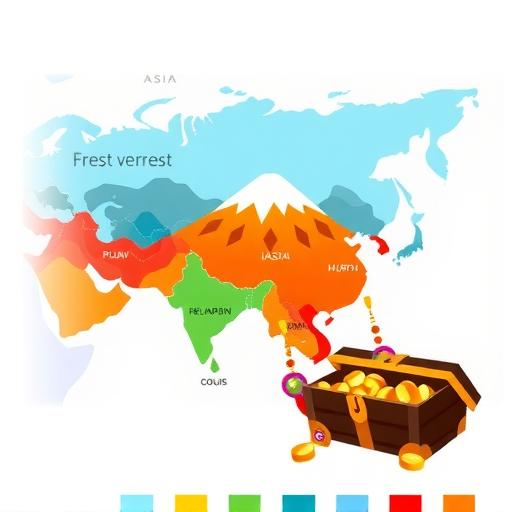


✅ Test passed: T4: Image trigger ('draw', 7-10, EN)

────────────────────────────────────────────────────────────
🧪 TEST: T5: Missing info fallback
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: What is the population of Mars and who lives there?

📤 Output format: TEXT



Не намирам това в материала. 🌐 Ето какво знам по темата:

Твоят въпрос е за **Марс** — червеният планета в нашата Слънчева система. Документът, който имам, обаче говори за **Азия** — един от континентите на Земята.

🌐 **По отношение на Марс:**
- Марс е необитаем планета — там няма население и никой не живее
- Досега не са открити признаци на живот там
- Някои космически мисии изследват планетата, но няма постоянни население

**Заключение:** Материалът ми не съдържа информация за Марс, защото говори за география на Земята. Ако имаш въпроси за **население на Азия, релефа ѝ или полезни изкопаеми**, охотно мога да ти помогна! 😊


✅ Test passed: T5: Missing info fallback

────────────────────────────────────────────────────────────
🧪 TEST: T6: Mixed 📄/🌐 attribution (16+, EN)
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: Summarise what this document covers and add any related context you know

📤 Output format: TEXT



# Document Summary: Asia's Geography

## What This Document Covers

📄 **From the document:** This is an educational text about Asia covering:

1. **Geographic Position & Size**
   - Asia is the largest continent on Earth (~44.4 million km²)
   - Located almost entirely in the Northern Hemisphere and Eastern Hemisphere
   - Stretches from Arctic regions to equatorial zones

2. **Coastlines & Major Features**
   - Bordered by Arctic Ocean (north), Pacific Ocean (east), Indian Ocean (south)
   - Contains major peninsulas (Indochina, Hindustan, Kamchatka, Korea, Arabian Peninsula)
   - Home to the largest archipelago on Earth (Malay Archipelago)
   - Notable straits like Bering Strait (86 km wide) separate it from North America

3. **Relief & Landforms**
   - Extremely diverse terrain called "land of contrasts"
   - Contains Mount Everest (8,848 m) — Earth's highest peak
   - Contains Dead Sea depression (-430 m)
   - 3/4 of territory consists of mountains, plateaus, and hills
   - Major mountain ranges: Himalayas, Urals, Tian Shan

4. **Geological Activity**
   - Active earthquake and volcanic zones, especially in East and Southeast Asia
   - Indonesia alone has over 130 active volcanoes, including Krakatau
   - Young mountain formations (Himalayas) still experience intense tectonic activity

5. **Exploration History**
   - Ancient Greeks provided first Western knowledge
   - Silk Road trade connected Romans with China (~2000 years ago)
   - Marco Polo's travels (1271-1295)
   - 19th-century Russian explorer Pyotr Semyonov-Tyan-Shansky studied central Asia
   - Everest summits: first ascent in 1953 (Hillary & Tenzing Norgey); Bulgarian expedition in 1984

---

## 🌐 Additional Context (General Knowledge)

To enrich your understanding:

- **Tectonic Significance:** The document hints at the Ring of Fire concept—Asia's Pacific coastline marks one of Earth's most seismically active zones due to collision between the Pacific and Eurasian plates.

- **Climate Zones:** Asia's vast latitudinal span creates all major climate types, from arctic tundra to tropical rainforests, affecting biodiversity and human settlement patterns.

- **Geopolitical Importance:** The document mentions the Bering Strait and strategic waterways (Suez Canal)—these remain crucial for global trade and geopolitics today.

- **Modern Mountaineering:** The 1953 Everest conquest is considered mountaineering's greatest achievement; the document's reference to Bulgarian climbers reflects Asia's role in modern adventure sports.

**Is there a specific section you'd like me to explain in more detail?**


✅ Test passed: T6: Mixed 📄/🌐 attribution (16+, EN)

────────────────────────────────────────────────────────────
🧪 TEST: T7: BG + engagement-first profile
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: Защо Япония е важна страна?

📤 Output format: TEXT



# Япония - защо е играч на световната сцена?

**HOOK:** Представи си, че света е едно голямо стратегическо игрище - Япония е като королица на шах, позиционирана перфектно за контрол. 🎮

---

## Географската суперсила 🌍

📄 От документа: Япония е част от **японските острови** - един от най-големите архипелаги в Азия. Разположена е в Източна Азия, където земетресенията и вулканите са честа дума. Звучи опасно, но точно това я прави **стратегически критична** - контролира морските пътища на Тихия океан.

🌐 Допълнително: Японския архипелаг е като щит между Китай и открития Тихи океан. Всеки превоз на стоки от или към Азия практически минава покрай нея.

---

## Минерално богатство 💎

📄 През документа се споменава, че в Япония има **сяра и активни вулкани**. Нефтта и природния газ на региона около Япония идват от Персийския залив и Малайския архипелаг - но Япония е **логистичния мост** за разпространение.

🌐 Прост факт: Япония нямал много суровини сама, но това я научи да превърне импорта в експорт на технология - от чипсове до роботи.

---

## Защо трябва да й обърнеш внимание?

**Ти вече разбираш нещо, което много история учебници пропускат:** географията създава мощни държави не защото имат злато, а защото имат *позиция*. Япония е живо доказателство за това правило. 🏆


✅ Test passed: T7: BG + engagement-first profile

────────────────────────────────────────────────────────────
🧪 TEST: T8: Adult learner (30+, EN, professional tone)
────────────────────────────────────────────────────────────
✅ Format: expected=text, got=text

❓ Question: Give me a concise professional summary of this document's core content

📤 Output format: TEXT



# Summary of Document Content

## Core Topic
📄 **Geography of Asia** — a comprehensive overview covering physical characteristics, geological formation, and historical exploration of the continent.

## Main Sections

**Geographic Position & Scale**
- 📄 Asia is Earth's largest continent (~44.4 million km²—30% of land surface)
- 📄 Spans from Arctic to equatorial regions; positioned in Eastern Hemisphere
- 📄 Bordered by Arctic, Pacific, and Indian Oceans; connected to Europe via land

**Relief & Terrain Features**
- 📄 Characterized as "land of contrasts" with extreme elevation variation:
  - Highest: Mt. Everest (8,848 m)
  - Lowest: Dead Sea depression (-430 m)
- 📄 ~75% comprises high mountains, plateaus, and hills
- 📄 Contains all peaks exceeding 7,000 m globally

**Geological Formation**
- 📄 Complex history involving ancient supercontinent Laurasia and fragments from Gondwana
- 📄 Young mountain ranges (Himalayas, Tibetan plateau) formed 65+ million years ago from tectonic plate collisions
- 📄 Major active geological zones: southeastern Asia experiences frequent earthquakes and volcanic activity (e.g., Krakatau—130+ active volcanoes in Indonesia alone)

**Historical Exploration**
- 📄 Early knowledge from ancient Greeks; Silk Road trade (Roman era); Marco Polo (1271-1295); notable 19th-century Russian explorer Pyotr Semenov-Tyan-Shansky
- 📄 First Everest summit: 1953; Bulgarian expeditions documented in 1984

**Coverage gaps:** Limited economic/cultural content in this extract.


✅ Test passed: T8: Adult learner (30+, EN, professional tone)

📊 TEST SUMMARY: 8/8 passed
  ✅ T1
  ✅ T2
  ✅ T3
  ✅ T4
  ✅ T5
  ✅ T6
  ✅ T7
  ✅ T8


In [ ]:
# ─── Run all 8 tests ──────────────────────────────────────────────────────────
test_results = {}

# T1: Simple factual → text, engagement-first profile
test_results["T1"] = run_test(
    test_name="T1: Simple factual (default_engagement, BG, text)",
    question="Какво е най-важното в този документ?",
    profile_key="default_engagement",
    language="bg",
    expected_format="text",
)

# T2: Complex explanation → text, older audience
test_results["T2"] = run_test(
    test_name="T2: Complex explanation (16+, EN, text)",
    question="Explain how the main concepts in this document are interconnected.",
    profile_key="16+",
    language="en",
    expected_format="text",
)

# T3: Audio trigger
test_results["T3"] = run_test(
    test_name="T3: Audio trigger ('tell me', 10-16, EN)",
    question="Tell me about the key ideas in this document",
    profile_key="10-16",
    language="en",
    expected_format="audio",
)

# T4: Image trigger
test_results["T4"] = run_test(
    test_name="T4: Image trigger ('draw', 7-10, EN)",
    question="Draw an illustration showing the main concept from this document",
    profile_key="7-10",
    language="en",
    expected_format="image",
)

# T5: Missing information fallback
test_results["T5"] = run_test(
    test_name="T5: Missing info fallback",
    question="What is the population of Mars and who lives there?",
    profile_key="10-16",
    language="en",
    expected_format="text",
)

# T6: Mixed source attribution
test_results["T6"] = run_test(
    test_name="T6: Mixed 📄/🌐 attribution (16+, EN)",
    question="Summarise what this document covers and add any related context you know",
    profile_key="16+",
    language="en",
    expected_format="text",
)

# T7: Bulgarian + engagement-first profile
test_results["T7"] = run_test(
    test_name="T7: BG + engagement-first profile",
    question="Защо Япония е важна страна?",
    profile_key="default_engagement",
    language="bg",
    expected_format="text",
)

# T8: Adult learner, concise tone
test_results["T8"] = run_test(
    test_name="T8: Adult learner (30+, EN, professional tone)",
    question="Give me a concise professional summary of this document's core content",
    profile_key="30+",
    language="en",
    expected_format="text",
)

# Summary
passed = sum(1 for v in test_results.values() if v)
total  = len(test_results)
print(f"\n{'='*60}")
print(f"📊 TEST SUMMARY: {passed}/{total} passed")
print(f"{'='*60}")
for test_id, result in test_results.items():
    icon = "✅" if result else "❌"
    print(f"  {icon} {test_id}")


---
## 🔬 Section 12 — Engineering Deep Dives

For engineering students who want to inspect system internals.
Not required for the end-user experience.


In [ ]:
# ─── Deep Dive 1: Inspect chunks ─────────────────────────────────────────────
# See exactly how the document was split. Helps tune CHUNK_SIZE and CHUNK_OVERLAP.

print(f"Total vectors in store: {collection.count()}")
print(f"\nFirst 3 chunks:\n")

for chunk in chunks[:3]:
    print(f"ID: {chunk['chunk_id']} | Page: {chunk['page']}")
    print(f"Length: {len(chunk['text'])} chars (~{len(chunk['text'])//4} tokens)")
    print(f"Preview: {chunk['text'][:200]}...")
    print("─" * 50)


Total vectors in store: 9

First 3 chunks:

ID: chunk_0 | Page: 1
Length: 2400 chars (~600 tokens)
Preview: ографско положение, големина брегове и опознаване на Азия Географско положение Азия ¢ най-обширният континент на Земята. Той се прости- ра почти изцяло в Северното полукълбо с изключение на някон от н...
──────────────────────────────────────────────────
ID: chunk_1 | Page: 1
Length: 485 chars (~121 tokens)
Preview: континенти. Заедно Нос fens с обширната територия това обуславя голямата отдалеченост на централните части на континента от крайбрежието, която дос 00 км. Островите и полуостровите са приблизи- Teo 1/...
──────────────────────────────────────────────────
ID: chunk_2 | Page: 2
Length: 2400 chars (~600 tokens)
Preview: до тихооксанските брегове на Азия. По-големи сред тях са Япопските и Филипипските остройи. Най-големите полуострови Камчатка и Корея. Корейският полуостров обгражца от изток боко вдаденото в сушат: то...
──────────────────────────────────────────────────


In [ ]:
# ─── Deep Dive 2: Visualise retrieval ───────────────────────────────────────
# See which chunks are retrieved for a query and their similarity scores.
# Change test_query to explore how retrieval responds to different phrasings.

test_query = "Explain the main concept"   # ← change this

print(f"Query: '{test_query}'\n")
retrieved_demo = retrieve_chunks(test_query, collection, embedding_model, top_k=cfg.TOP_K)

for i, chunk in enumerate(retrieved_demo, 1):
    bar_length = int(chunk["similarity"] * 40)
    bar = "█" * bar_length + "░" * (40 - bar_length)
    print(f"Chunk {i} | Page {chunk['page']} | Similarity: {chunk['similarity']:.2%}")
    print(f"[{bar}]")
    print(f"{chunk['text'][:200]}...")
    print()


Query: 'Explain the main concept'

Chunk 1 | Page 5 | Similarity: 8.47%
[███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
Полезни изкопаеми Полезни изкопаеми (Вижте 1 от урок 32.) Голямата площ и сложната гео- ложка история са причини за огромното и разнообразно минс- рално богатство на континента. Азия заема водещо мяст...

Chunk 2 | Page 5 | Similarity: 4.35%
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
до изменения в релефа сксплоатацията на полезни изкопасми води и до замърсяванс на въздуха, водите и почвите. А) военна 1. Посочете причините за голямото р копзсми в Азия. разнообразие на полезните из...

Chunk 3 | Page 2 | Similarity: 3.30%
[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
до тихооксанските брегове на Азия. По-големи сред тях са Япопските и Филипипските остройи. Най-големите полуострови Камчатка и Корея. Корейският полуостров обгражца от изток боко вдаденото в сушат: то...

Chunk 4 | Page 1 | Similarity: 2.49%
[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
континенти. Заедно Нос fens с 

In [ ]:
# ─── Deep Dive 3: Inspect embedding vectors ─────────────────────────────────
# Peek at the actual numbers inside an embedding.
# This demystifies what a "vector" really is.

sample_text = "This is an educational example sentence."
embedding   = embedding_model.encode(sample_text)

print(f"Input text  : '{sample_text}'")
print(f"Shape       : {embedding.shape}  ({embedding.dtype})")
print(f"First 10 / {len(embedding)} values:")
print([round(float(v), 4) for v in embedding[:10]])
print(f"Value range : [{float(embedding.min()):.4f}, {float(embedding.max()):.4f}]")
print(
    f"\nEngineering insight: Each of the {len(embedding)} numbers encodes a different "
    f"semantic feature. Similar sentences produce similar patterns across all dimensions."
)


Input text  : 'This is an educational example sentence.'
Shape       : (384,)  (float32)
First 10 / 384 values:
[0.0919, 0.1023, 0.051, 0.0969, -0.0059, -0.0226, 0.0136, -0.0102, 0.0697, 0.0518]
Value range : [-0.1515, 0.1220]

Engineering insight: Each of the 384 numbers encodes a different semantic feature. Similar sentences produce similar patterns across all dimensions.


In [ ]:
# ─── Deep Dive 4: Cosine similarity from scratch ─────────────────────────────
# Demonstrates WHY cosine similarity captures meaning better than Euclidean distance.
# Two sentences of different lengths but similar meaning should score high;
# Euclidean distance penalises length — cosine similarity does not.

def cosine_similarity_manual(a, b) -> float:
    """cos(θ) = (A · B) / (|A| × |B|) — measures angle, not magnitude."""
    import numpy as np
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


pairs = [
    ("A dog runs in the park",               "A canine sprints through the garden"),
    ("The sky is blue",                       "Machine learning is fascinating"),
    ("Photosynthesis converts sunlight to energy", "Plants use light to make food"),
]

print("Cosine Similarity Demonstration\n" + "=" * 50)
for s1, s2 in pairs:
    e1  = embedding_model.encode(s1)
    e2  = embedding_model.encode(s2)
    sim = cosine_similarity_manual(e1, e2)
    bar = "█" * int(sim * 30)
    print(f"\nA: '{s1}'")
    print(f"B: '{s2}'")
    print(f"Similarity: {sim:.4f}  [{bar}]")


Cosine Similarity Demonstration

A: 'A dog runs in the park'
B: 'A canine sprints through the garden'
Similarity: 0.5477  [████████████████]

A: 'The sky is blue'
B: 'Machine learning is fascinating'
Similarity: 0.0941  [██]

A: 'Photosynthesis converts sunlight to energy'
B: 'Plants use light to make food'
Similarity: 0.5480  [████████████████]


---
## 🚀 Section 13 — Future Extensions

### 1. Query Rewriting
Ask Claude to rephrase the question before embedding — removes filler words
so the embedding vector matches document chunks more precisely:
```python
def rewrite_query(question: str, client) -> str:
    # "Can you explain what the thing about energy is?"
    # → "energy definition and transfer mechanism"
```

### 2. Hybrid Retrieval
Combine dense (vector) search with sparse (BM25 keyword) search,
then merge with Reciprocal Rank Fusion for best of both worlds.

### 3. Conversation Memory
Include the last N turns in the LLM prompt so follow-up questions work:
`"Tell me more about the second point you mentioned"`

### 4. Persistent Vector Store
```python
chroma_client = chromadb.PersistentClient(path="./chroma_db")
# Survives Colab runtime restarts — no re-indexing needed
```

### 5. Dynamic Profile Customisation
Allow teachers to define new learner profiles via a JSON form in the notebook,
without editing code. Each profile is a prompt snippet — entirely data-driven.

### 6. Production Deployment
- **Backend**: FastAPI with async streaming responses
- **Frontend**: React with Server-Sent Events for token-by-token display
- **Storage**: PostgreSQL + pgvector for production-scale vector search
- **Auth**: JWT tokens for per-student session management


In [ ]:
# ─── Bonus: Query rewriting (extension implementation) ───────────────────────
# Demonstrates how to improve retrieval quality with minimal additional code.

def rewrite_query_for_retrieval(question: str, client: anthropic.Anthropic) -> str:
    """Rewrite a conversational question into a concise retrieval query.

    Engineering insight:
        Conversational questions contain filler words and implicit references
        that degrade embedding quality. A keyword-rich rewrite matches document
        chunks much more precisely.

        Example:
            Input:  "Can you explain what the thing about energy transfer is?"
            Output: "energy transfer process definition and mechanism"

    Args:
        question: The user's original question.
        client:   Anthropic API client.

    Returns:
        A concise, keyword-rich retrieval query string.
    """
    response = client.messages.create(
        model=cfg.CLAUDE_MODEL,
        max_tokens=100,
        messages=[{
            "role": "user",
            "content": (
                "Rewrite this question as a concise, keyword-rich search query "
                "for a document retrieval system. Output ONLY the query, nothing else.\n\n"
                f"Question: {question}"
            ),
        }],
    )
    return response.content[0].text.strip()


# Demonstration
original  = "Can you explain what that thing about how plants make food is all about?"
rewritten = rewrite_query_for_retrieval(original, claude)
print(f"Original : {original}")
print(f"Rewritten: {rewritten}")
print("\n💡 The rewritten query matches document chunks more accurately.")


Original : Can you explain what that thing about how plants make food is all about?
Rewritten: photosynthesis plant food production process

💡 The rewritten query matches document chunks more accurately.


---

## 📋 Quick Reference Card

| Function | Purpose | Key arguments |
|---|---|---|
| `extract_text_from_pdf(path)` | PDF → page list | `pdf_path` |
| `chunk_text(pages, size, overlap)` | Pages → overlapping chunks | `chunk_size`, `overlap` |
| `load_embedding_model(name)` | Load SentenceTransformer | `model_name` |
| `build_vector_store(chunks, model, name)` | Embed + store in ChromaDB | `chunks`, `embedding_model` |
| `retrieve_chunks(query, coll, model, k)` | Top-k similarity search | `query`, `top_k` |
| `retrieve_information(...)` | Full RAG pipeline | `question`, `profile_key`, `language` |
| `load_xtts_model()` | Load fine-tuned XTTS v2 (cached) | — |
| `parse_intent(q, client)` | Detect output format | `question` |
| `ask_ai(...)` | Master dispatcher | all above + `speaker_wav` |

**Learner profiles:** `default_engagement` · `7-10` · `10-16` · `16+` · `30+`

---

*Built with Claude API · ChromaDB · SentenceTransformers · Coqui XTTS v2 · HuggingFace FLUX*
